<a href="https://colab.research.google.com/github/shrutisingh004/house-type-prediction/blob/main/training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")
print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "AB_NYC_2019.csv"))

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data


In [ ]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:
df.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


In [ ]:
df.shape

(48895, 16)

EDA

In [ ]:
# 1. Missing Values

missing = df.isnull().sum()
missing[missing > 0]

,0
name,16
host_name,21
last_review,10052
reviews_per_month,10052


<Axes: xlabel='room_type', ylabel='count'>

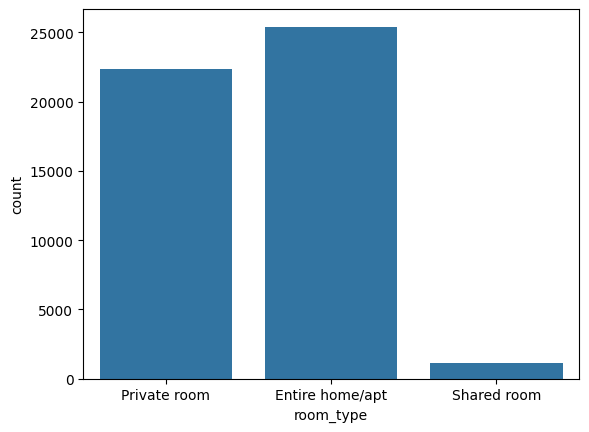

In [ ]:
# 2. Target Value - Room Type

df['room_type'].value_counts()
sns.countplot(x='room_type', data=df)

- This is the case of class imbalance
- Shared room -> small minority

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

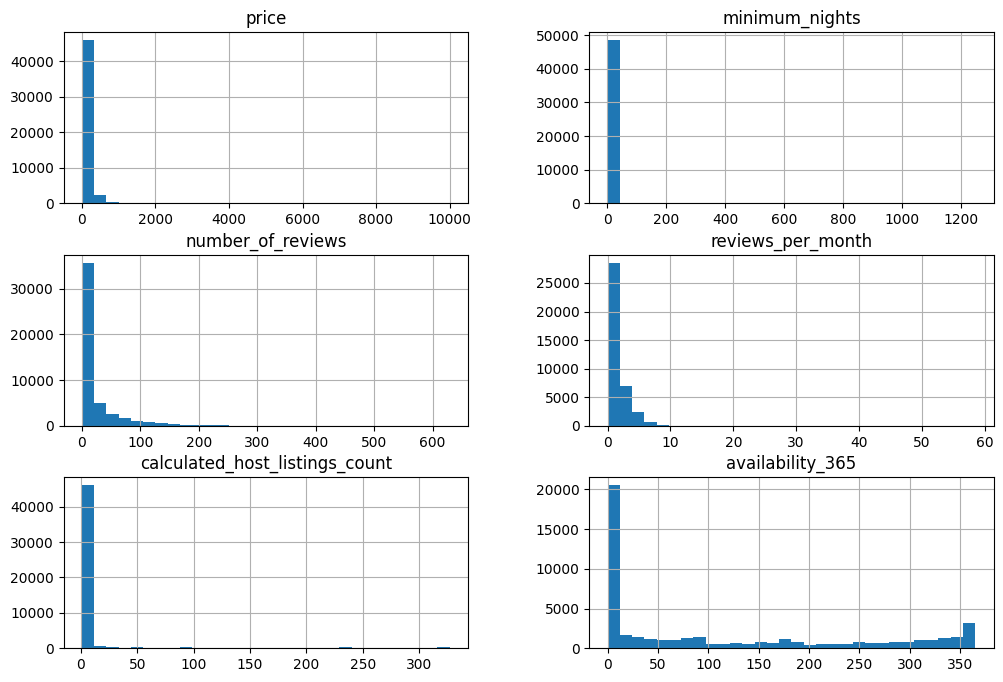

In [ ]:
# 3. Univariate Analysis (only Numerical features)

numerical_cols = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365"]
df[numerical_cols].hist(bins=30, figsize=(12,8))

<Axes: xlabel='neighbourhood_group', ylabel='count'>

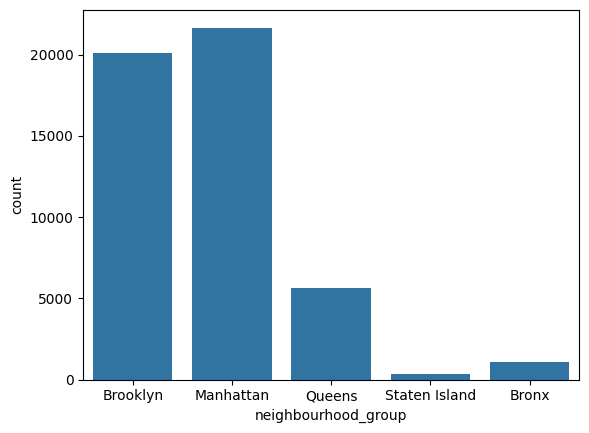

In [ ]:
# 4. Univariate Analysis (only Categorical features)

sns.countplot(data=df, x='neighbourhood_group')

<Axes: xlabel='room_type', ylabel='price'>

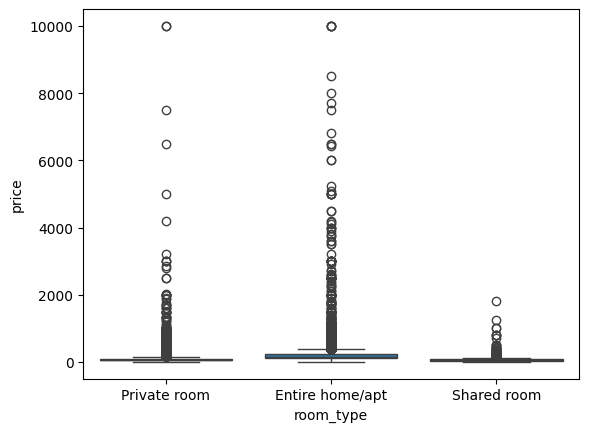

In [ ]:
# 5. Bivariate Analysis (Features vs Target)

sns.boxplot(x='room_type', y='price', data=df)

<Axes: >

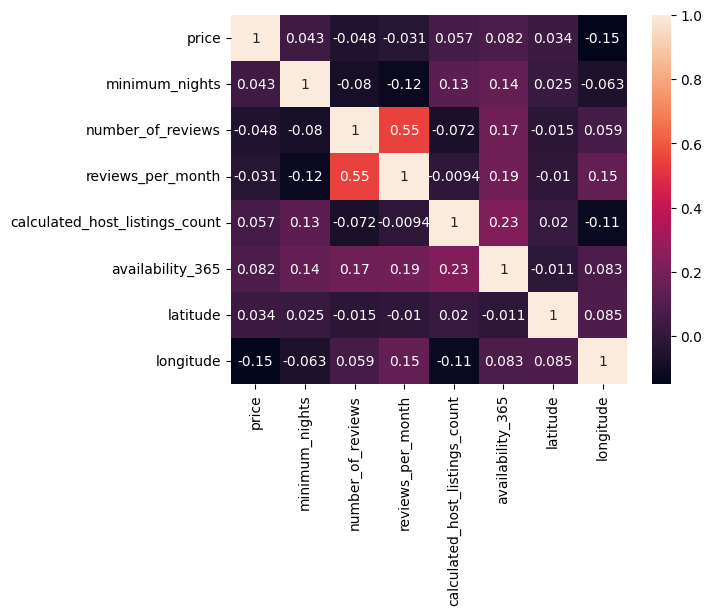

In [ ]:
# 6. Correlation map

corr = df[numerical_cols + ['latitude', 'longitude']].corr()
sns.heatmap(corr, annot=True)

<Axes: xlabel='longitude', ylabel='latitude'>

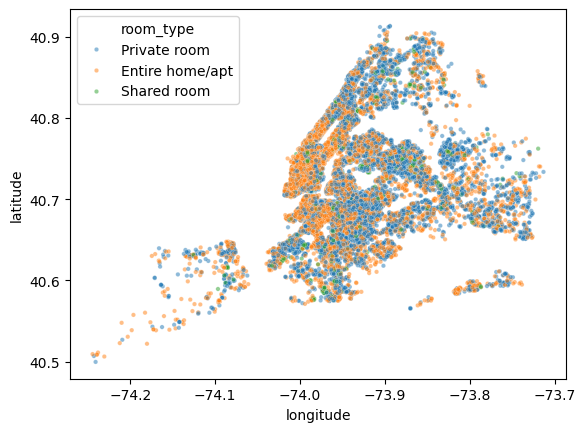

In [ ]:
# 7. Geographical Distribution

sns.scatterplot(x='longitude', y='latitude', data=df, hue='room_type', alpha=0.5, s=10)

Data Cleaning & Feature Engineering

In [ ]:
# 1. Dropping columns that are of no use
df_clean = df.drop(columns=['id', 'name', 'host_name', 'last_review'])

In [ ]:
# 2. No reviews yet -> 0 reviews per month; not missing
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

In [ ]:
# 3. Capping extreme outliers instead of deleting rows
price_cap = df_clean['price'].quantile(0.99)
nights_cap = df_clean['minimum_nights'].quantile(0.99)

df_clean['price'] = df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=nights_cap)

In [ ]:
df_clean

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
48890,8232441,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,0.00,2,9
48891,6570630,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,0.00,2,36
48892,23492952,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,0.00,1,27
48893,30985759,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,0.00,6,2


In [ ]:
X = df_clean.drop(columns=['room_type'])
y = df_clean['room_type']

Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

Preprocessing: ColumnTransformer + Pipeline

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
numerical_cols = numerical_cols + ['latitude', 'longitude']
categorical_cols = ['neighbourhood_group', 'neighbourhood']

In [ ]:
df_clean[numerical_cols].skew()

,0
price,2.776321
minimum_nights,2.360347
number_of_reviews,3.690635
reviews_per_month,3.300723
calculated_host_listings_count,7.933174
availability_365,0.763408
latitude,0.237167
longitude,1.284210


In [ ]:
# Pipeline 1 : Numerical Columns
numerical_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

# Pipeline 2 : Categorical Columns
categorical_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('numerical', numerical_pipeline, numerical_cols),
    ('categorical', categorical_pipeline, categorical_cols)
])

In [ ]:
preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['price', 'minimum_nights',
                                  'number_of_reviews', 'reviews_per_month',
                                  'calculated_host_listings_count',
                                  'availability_365', 'latitude',
                                  'longitude']),
                                ('categorical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'neighbourhood'])])

Trying Multiple Algorithms

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

In [ ]:
models = {
    "Logistic Regression" : LogisticRegression(class_weight="balanced", random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest"       : RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
  pipe = Pipeline(steps=[
      ('preprocess', preprocessor),
      ('model', model)
  ])

  accuracy = cross_val_score(pipe, X_train, y_train, cv=3, scoring='accuracy')
  macrof1 = cross_val_score(pipe, X_train, y_train, cv=3, scoring='f1_macro')

  print(f"{name} -> Accuracy: {accuracy.mean():.3f} , F1: {macrof1.mean():.3f}")

Logistic Regression -> Accuracy: 0.663 , F1: 0.526
Decision Tree -> Accuracy: 0.783 , F1: 0.649
Random Forest -> Accuracy: 0.853 , F1: 0.719
Gradient Boosting -> Accuracy: 0.850 , F1: 0.708


Hyperparamter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(class_weight="balanced"))
])

param_grid = {
    'model__n_estimators' : [100, 150, 200, 300],
    'model__max_depth' : [8, 12, 15, 20, None],
    'model__min_samples_split' : [2, 5, 10]
}

search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_grid,
    cv=3,
    scoring='f1_macro',
    random_state=42
    )
search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('numerical',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['price',
                                                                                'minimum_nights',
                                                                                'number_of_reviews',
                                                                                'reviews_per_month',
                                                                                'calculated_host_listings_count',
                                                                                'availability_365',
                                                                                'latitude',
                                                                                'longitude']),
                                                                              ('categor...
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encode',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['neighbourhood_group',
                                                                                'neighbourhood'])])),
                                             ('model',
                                              RandomForestClassifier(class_weight='balanced'))]),
                   param_distributions={'model__max_depth': [8, 12, 15, 20,
                                                             None],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 150, 200,
                                                                300]},
                   random_state=42, scoring='f1_macro')

In [ ]:
print(search.best_params_)
print("Best CV Macro-F1 : ", search.best_score_)

{'model__n_estimators': 150, 'model__min_samples_split': 10, 'model__max_depth': None}
Best CV Macro-F1 :  0.7373252777870185


Evaluation on the Test Set

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix,f1_score

best_pipeline = search.best_estimator_
y_pred = best_pipeline.predict(X_test)

print(f"Accuracy Score : {accuracy_score(y_test, y_pred)}")
print(f"F1 Score : {f1_score(y_test, y_pred, average="macro")}")

Accuracy Score : 0.8588812762041108
F1 Score : 0.7543309546990123


<Axes: >

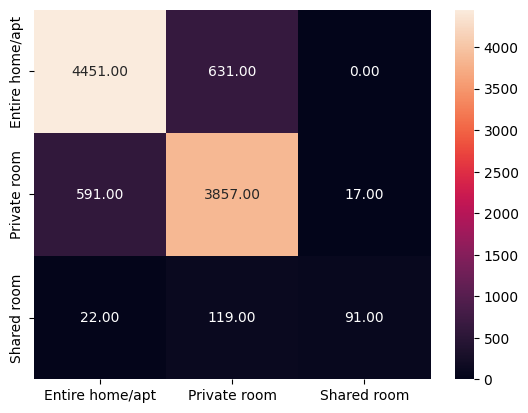

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt=".2f", xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)

Saving Final Model

In [ ]:
import joblib
joblib.dump(best_pipeline, "model.pkl", compress=3)

['model.pkl']